# OpenCV Scene Stitcher

Notebook này dùng `cv2.Stitcher` của OpenCV để thử ghép panorama trên từng scene trong `data/raw`.

Output sẽ được tách riêng theo đúng cấu trúc hiện tại của dự án:
- panorama: `outputs/openCV/panoramas/`
- log JSON: `outputs/openCV/logs/`

Notebook ưu tiên thứ tự ảnh trong `meta.json`. Nếu scene chưa có `meta.json`, notebook sẽ fallback sang sort theo tên file.

## Workflow

Notebook được chia thành nhiều module nhỏ để dễ hiểu và dễ debug:

1. `Imports`: nạp thư viện cần thiết.
2. `Paths`: tìm project root và tạo thư mục output cho OpenCV.
3. `Metadata helpers`: đọc `meta.json` và xác định thứ tự ảnh.
4. `Dataset inventory`: xem nhanh toàn bộ scene và nhãn `success / hard_valid / failure` trước khi chọn scene.
5. `User config`: chọn `SCENE_ID`, resize và chế độ stitch.
6. `Image utilities`: resize, đổi màu và thống kê ảnh đầu vào.
7. `Pair diagnostics`: đo chất lượng match giữa từng cặp ảnh liền kề.
8. `Preview`: xem nhanh strip ảnh của một scene.
9. `Scene runner`: chạy OpenCV Stitcher trên một scene và lưu log.
10. `Batch runner`: chạy toàn bộ scene nếu cần.

In [27]:
from pathlib import Path
import sys
import json
from datetime import datetime

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["axes.grid"] = False

## Module 1: Paths

Cell này làm 3 việc:
- tìm `PROJECT_ROOT`
- trỏ đến `data/raw`
- đảm bảo folder output cho nhánh `openCV` đã tồn tại

In [28]:
def find_project_root(start: Path) -> Path:
    candidates = [start.resolve(), start.resolve().parent]
    for candidate in candidates:
        if (candidate / "data" / "raw").exists():
            return candidate
    raise FileNotFoundError("Could not find project root containing data/raw")


PROJECT_ROOT = find_project_root(Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from project_utils.panorama_dataset import list_scene_dirs, ordered_scene_files

RAW_DIR = PROJECT_ROOT / "data" / "raw"
OUTPUT_PANORAMA_DIR = PROJECT_ROOT / "outputs" / "openCV" / "panoramas"
OUTPUT_LOG_DIR = PROJECT_ROOT / "outputs" / "openCV" / "logs"

OUTPUT_PANORAMA_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_LOG_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("RAW_DIR:", RAW_DIR)
print("OUTPUT_PANORAMA_DIR:", OUTPUT_PANORAMA_DIR)
print("OUTPUT_LOG_DIR:", OUTPUT_LOG_DIR)

PROJECT_ROOT: F:\CV\School\Project
RAW_DIR: F:\CV\School\Project\data\raw
OUTPUT_PANORAMA_DIR: F:\CV\School\Project\outputs\openCV\panoramas
OUTPUT_LOG_DIR: F:\CV\School\Project\outputs\openCV\logs


## Module 2: Metadata Helpers

Các hàm ở đây dùng để:
- đọc `meta.json`
- lấy đúng thứ tự ảnh của scene
- ánh xạ mã lỗi của OpenCV sang tên dễ đọc hơn

In [29]:
STATUS_NAMES = {
    int(cv2.Stitcher_OK): "OK",
    int(cv2.Stitcher_ERR_NEED_MORE_IMGS): "ERR_NEED_MORE_IMGS",
    int(cv2.Stitcher_ERR_HOMOGRAPHY_EST_FAIL): "ERR_HOMOGRAPHY_EST_FAIL",
    int(cv2.Stitcher_ERR_CAMERA_PARAMS_ADJUST_FAIL): "ERR_CAMERA_PARAMS_ADJUST_FAIL",
}


def stitcher_mode_value(mode_name: str) -> int:
    mode_name = mode_name.upper().strip()
    if mode_name == "SCANS":
        return int(cv2.Stitcher_SCANS)
    return int(cv2.Stitcher_PANORAMA)

## Module 3: Dataset Inventory

Cell này được đặt lên đầu để bạn xem nhanh toàn bộ scene hiện có trước khi chọn `SCENE_ID`.

Bảng sẽ hiển thị:
- `scene_id`
- số lượng ảnh và ảnh reference
- `capture_group`, `category`, `difficulty`
- trạng thái snapshot hiện tại trong `meta.json`
- `ok_rate`, `stability_label`, `output_consistent`
- mục đích sử dụng của scene


In [30]:
def build_scene_table() -> pd.DataFrame:
    rows = []
    for scene_dir in list_scene_dirs(RAW_DIR):
        files, reference_files, meta, used_meta_order = ordered_scene_files(scene_dir)
        audit_summary = meta.get("audit_summary", {}) or {}
        stability = audit_summary.get("stability_check", {}) or {}
        rows.append(
            {
                "scene_id": scene_dir.name,
                "num_images": len(files),
                "num_reference_images": len(reference_files),
                "capture_group": meta.get("capture_group"),
                "category": meta.get("category"),
                "difficulty": meta.get("difficulty"),
                "stitcher_status": audit_summary.get("stitcher_status"),
                "ok_rate": stability.get("ok_rate"),
                "stability_label": stability.get("stability_label"),
                "output_consistent": stability.get("is_output_consistent"),
                "recommended_use": meta.get("recommended_use"),
                "used_meta_order": used_meta_order,
            }
        )

    columns = [
        "scene_id",
        "num_images",
        "num_reference_images",
        "capture_group",
        "category",
        "difficulty",
        "stitcher_status",
        "ok_rate",
        "stability_label",
        "output_consistent",
        "recommended_use",
        "used_meta_order",
    ]
    return pd.DataFrame(rows)[columns].sort_values("scene_id").reset_index(drop=True)


scene_table = build_scene_table()
display(scene_table)


,scene_id,num_images,num_reference_images,capture_group,category,difficulty,stitcher_status,ok_rate,stability_label,output_consistent,recommended_use,used_meta_order
0,scene_01,6,0,core,success,medium,OK,1.0,stable_success,True,core_benchmark,True
1,scene_02,3,0,core,hard_valid,medium,ERR_NEED_MORE_IMGS,0.8,unstable_mix,False,core_hard_benchmark,True
2,scene_03,4,0,core,success,easy,OK,1.0,success_with_output_variation,False,core_benchmark,True
3,scene_04,3,0,core,failure,hard,ERR_NEED_MORE_IMGS,0.0,stable_failure,None,failure_analysis,True
4,scene_05,3,0,core,success,easy,OK,1.0,success_with_output_variation,False,core_benchmark,True
5,scene_06,4,0,core,hard_valid,hard,OK,1.0,success_with_output_variation,False,core_hard_benchmark,True
6,scene_07,3,0,core,failure,hard,ERR_NEED_MORE_IMGS,0.0,stable_failure,None,failure_analysis,True
7,scene_08,3,0,core,failure,hard,ERR_NEED_MORE_IMGS,0.0,stable_failure,None,failure_analysis,True
8,scene_09,30,0,large,success,medium,OK,1.0,stable_success,True,large_stress_test,True
9,scene_10,4,0,core,hard_valid,hard,OK,1.0,stable_success,True,core_hard_benchmark,True


## Module 4: User Config

Sau khi xem bảng inventory ở trên, bạn chỉnh cell này để chọn scene muốn test.

- `SCENE_ID`: scene muốn chạy thử
- `MAX_INPUT_WIDTH`: resize input trước khi đưa cho Stitcher
- `STITCHER_MODE`: `PANORAMA` hoặc `SCANS`
- `RUN_ALL_SCENES`: nếu `True`, notebook sẽ chạy toàn bộ dataset

In [31]:
SCENE_ID = "scene_28"
MAX_INPUT_WIDTH = 3000
STITCHER_MODE = "PANORAMA"  # "PANORAMA" or "SCANS"
SAVE_OUTPUTS = True
RUN_ALL_SCENES = False
SHOW_INPUT_STRIP = True


## Module 5: Image Utilities

Module này xử lý các thao tác cơ bản trên ảnh:
- resize giữ tỉ lệ
- đổi BGR sang RGB để hiển thị bằng matplotlib
- đo blur / brightness / contrast của từng ảnh

In [32]:
def resize_keep_aspect(image: np.ndarray, max_width: int) -> np.ndarray:
    height, width = image.shape[:2]
    if width <= max_width:
        return image
    scale = max_width / width
    return cv2.resize(
        image,
        (int(round(width * scale)), int(round(height * scale))),
        interpolation=cv2.INTER_AREA,
    )


def bgr_to_rgb(image: np.ndarray) -> np.ndarray:
    return cv2.cvtColor(image, cv2.COLOR_BGR2RGB)


def image_stats(image_bgr: np.ndarray, file_name: str) -> dict:
    gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)
    return {
        "file": file_name,
        "width": int(image_bgr.shape[1]),
        "height": int(image_bgr.shape[0]),
        "blur_score": round(float(cv2.Laplacian(gray, cv2.CV_64F).var()), 2),
        "brightness_mean": round(float(gray.mean()), 2),
        "contrast_std": round(float(gray.std()), 2),
    }


## Module 6: Pair Diagnostics

Cell này không dùng để stitch trực tiếp. Nó chỉ giúp chẩn đoán chất lượng chuỗi ảnh bằng cách:
- trích ORB keypoints
- match từng cặp ảnh liền kề
- ước lượng homography bằng RANSAC
- gán nhãn `strong / ok / weak / fail` cho từng cặp

In [33]:
def compute_pair_diagnostics(images_bgr, file_names):
    orb = cv2.ORB_create(nfeatures=4000, fastThreshold=10)
    matcher = cv2.BFMatcher(cv2.NORM_HAMMING)
    diagnostics = []

    prepared = []
    for image in images_bgr:
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        keypoints, descriptors = orb.detectAndCompute(gray, None)
        prepared.append((keypoints, descriptors))

    for index in range(len(images_bgr) - 1):
        keypoints_a, descriptors_a = prepared[index]
        keypoints_b, descriptors_b = prepared[index + 1]

        record = {
            "pair_index": index + 1,
            "image_a": file_names[index],
            "image_b": file_names[index + 1],
            "raw_matches": 0,
            "good_matches": 0,
            "inliers": 0,
            "inlier_ratio": 0.0,
            "homography_ok": False,
            "median_reproj_error": None,
            "pair_label": "fail",
        }

        if descriptors_a is None or descriptors_b is None or len(keypoints_a) < 8 or len(keypoints_b) < 8:
            diagnostics.append(record)
            continue

        raw_matches = matcher.knnMatch(descriptors_a, descriptors_b, k=2)
        good_matches = []
        for pair in raw_matches:
            if len(pair) < 2:
                continue
            first, second = pair
            if first.distance < 0.75 * second.distance:
                good_matches.append(first)

        record["raw_matches"] = int(len(raw_matches))
        record["good_matches"] = int(len(good_matches))

        if len(good_matches) >= 8:
            src = np.float32([keypoints_a[m.queryIdx].pt for m in good_matches]).reshape(-1, 1, 2)
            dst = np.float32([keypoints_b[m.trainIdx].pt for m in good_matches]).reshape(-1, 1, 2)
            homography, mask = cv2.findHomography(dst, src, cv2.RANSAC, 4.0)

            if mask is not None:
                inliers = int(mask.ravel().sum())
                record["inliers"] = inliers
                record["inlier_ratio"] = round(float(inliers / max(len(good_matches), 1)), 3)
                record["homography_ok"] = bool(homography is not None and inliers >= 8)

                if homography is not None and inliers > 0:
                    projected = cv2.perspectiveTransform(dst, homography)
                    errors = np.linalg.norm((projected - src).reshape(-1, 2), axis=1)
                    inlier_errors = errors[mask.ravel().astype(bool)]
                    if len(inlier_errors) > 0:
                        record["median_reproj_error"] = round(float(np.median(inlier_errors)), 3)

        if record["homography_ok"]:
            if record["inliers"] >= 40 and record["inlier_ratio"] >= 0.45:
                record["pair_label"] = "strong"
            elif record["inliers"] >= 18 and record["inlier_ratio"] >= 0.25:
                record["pair_label"] = "ok"
            else:
                record["pair_label"] = "weak"

        diagnostics.append(record)

    return diagnostics


## Module 7: Preview Helpers

Cell này hiển thị toàn bộ ảnh đầu vào của một scene theo dạng strip để bạn kiểm tra:
- thứ tự ảnh
- hướng ảnh
- mức overlap bằng mắt

In [34]:
def preview_scene(scene_id: str, max_width: int = 420):
    scene_dir = RAW_DIR / scene_id
    files, reference_files, _, _ = ordered_scene_files(scene_dir)

    figure, axes = plt.subplots(1, len(files), figsize=(max(4, 3 * len(files)), 4))
    if len(files) == 1:
        axes = [axes]

    for axis, file_path in zip(axes, files):
        image = cv2.imread(str(file_path))
        image = resize_keep_aspect(image, max_width)
        axis.imshow(bgr_to_rgb(image))
        axis.set_title(file_path.name, fontsize=8)
        axis.axis("off")

    figure.suptitle(scene_id)
    plt.tight_layout()
    plt.show()

    if reference_files:
        print("Reference files excluded from stitch chain:", [path.name for path in reference_files])

## Module 8: Scene Runner

Đây là phần chính của notebook. Hàm `run_scene()` sẽ:
- đọc ảnh từ một scene
- resize ảnh về `MAX_INPUT_WIDTH`
- gọi `cv2.Stitcher`
- tạo thống kê ảnh và pair diagnostics
- lưu panorama + file log JSON vào `outputs/openCV/`

In [35]:
def run_scene(scene_id: str, max_input_width: int = 1600, mode_name: str = "PANORAMA", save_outputs: bool = True):
    scene_dir = RAW_DIR / scene_id
    if not scene_dir.exists():
        raise FileNotFoundError(f"Scene not found: {scene_dir}")

    files, reference_files, meta, used_meta_order = ordered_scene_files(scene_dir)
    if len(files) < 2:
        raise ValueError(f"Scene {scene_id} must have at least 2 images")

    images_for_stitcher = []
    file_names = [path.name for path in files]

    for path in files:
        image = cv2.imread(str(path))
        if image is None:
            raise ValueError(f"Could not read image: {path}")
        images_for_stitcher.append(resize_keep_aspect(image, max_input_width))

    stitcher = cv2.Stitcher_create(stitcher_mode_value(mode_name))
    status_code, panorama = stitcher.stitch(images_for_stitcher)
    status_code = int(status_code)
    status_name = STATUS_NAMES.get(status_code, f"CODE_{status_code}")

    image_metrics = [image_stats(image, file_name) for image, file_name in zip(images_for_stitcher, file_names)]
    pair_metrics = compute_pair_diagnostics(images_for_stitcher, file_names)

    panorama_path = None
    panorama_shape = None
    panorama_rgb = None
    if status_code == int(cv2.Stitcher_OK) and panorama is not None:
        panorama_shape = {
            "width": int(panorama.shape[1]),
            "height": int(panorama.shape[0]),
        }
        panorama_rgb = bgr_to_rgb(panorama)
        if save_outputs:
            panorama_path = OUTPUT_PANORAMA_DIR / f"{scene_id}_opencv_{mode_name.lower()}.jpg"
            cv2.imwrite(str(panorama_path), panorama)

    meta_audit = meta.get("audit_summary", {}) or {}
    meta_stability = meta_audit.get("stability_check", {}) or {}

    summary = {
        "scene_id": scene_id,
        "scene_dir": str(scene_dir),
        "num_images": len(file_names),
        "num_reference_images": len(reference_files),
        "reference_files": [path.name for path in reference_files],
        "ordered_files": file_names,
        "used_meta_order": used_meta_order,
        "meta_capture_group": meta.get("capture_group"),
        "meta_category": meta.get("category"),
        "meta_difficulty": meta.get("difficulty"),
        "meta_recommended_use": meta.get("recommended_use"),
        "meta_notes": meta.get("notes"),
        "meta_stitcher_status": meta_audit.get("stitcher_status"),
        "meta_ok_rate": meta_stability.get("ok_rate"),
        "meta_stability_label": meta_stability.get("stability_label"),
        "meta_output_consistent": meta_stability.get("is_output_consistent"),
        "stitcher_mode": mode_name.upper(),
        "max_input_width": int(max_input_width),
        "status_code": status_code,
        "status_name": status_name,
        "panorama_shape": panorama_shape,
        "panorama_path": None if panorama_path is None else str(panorama_path),
        "image_stats": image_metrics,
        "pair_diagnostics": pair_metrics,
        "generated_at": datetime.now().isoformat(timespec="seconds"),
    }

    log_path = OUTPUT_LOG_DIR / f"{scene_id}_opencv_panorama_summary.json"
    if save_outputs:
        log_path.write_text(json.dumps(summary, indent=2), encoding="utf-8")

    display(Markdown(f"### {scene_id} | `{status_name}`"))
    display(pd.DataFrame(pair_metrics))

    if panorama_rgb is not None:
        plt.figure(figsize=(16, 7))
        plt.imshow(panorama_rgb)
        plt.title(f"{scene_id} panorama")
        plt.axis("off")
        plt.show()
    else:
        print("Stitcher did not return a panorama image.")

    if reference_files:
        print("Reference files excluded from stitch chain:", [path.name for path in reference_files])

    summary["log_path"] = str(log_path)
    return summary


## Preview Selected Scene

Nếu `SHOW_INPUT_STRIP = True`, cell này sẽ hiển thị toàn bộ ảnh trong `SCENE_ID`.

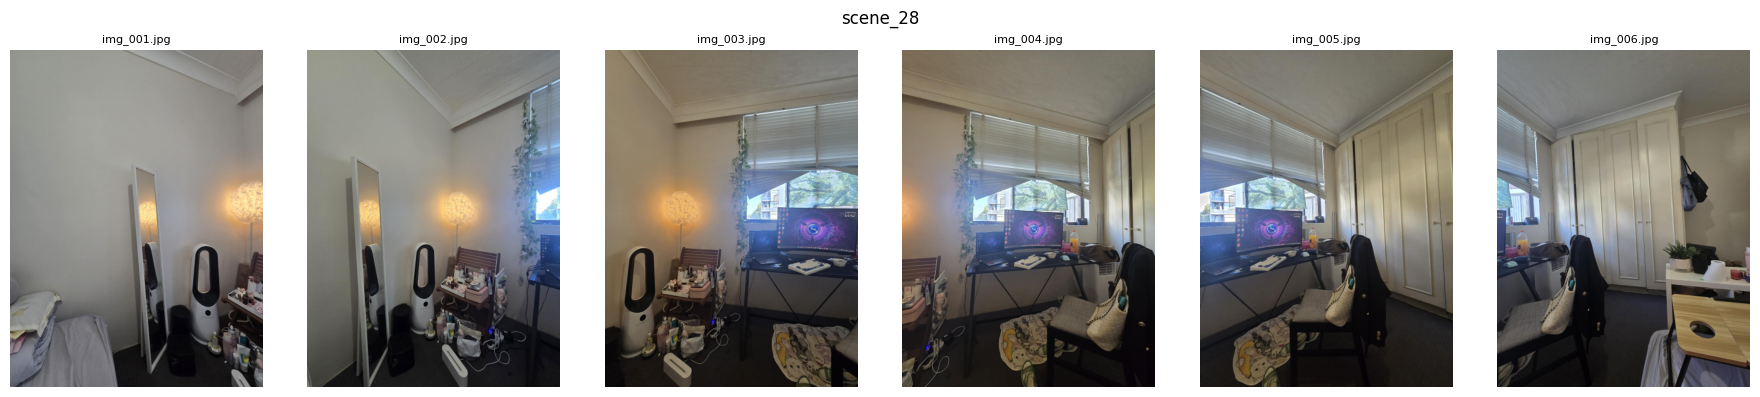

In [36]:
if SHOW_INPUT_STRIP:
    preview_scene(SCENE_ID)


## Run One Scene

Cell này chạy OpenCV Stitcher cho đúng một scene, hiển thị:
- status của stitcher
- metadata của scene
- pair diagnostics
- panorama nếu ghép thành công

### scene_28 | `OK`

,pair_index,image_a,image_b,raw_matches,good_matches,inliers,inlier_ratio,homography_ok,median_reproj_error,pair_label
0,1,img_001.jpg,img_002.jpg,4000,328,260,0.793,True,1.460,strong
1,2,img_002.jpg,img_003.jpg,4000,629,573,0.911,True,1.336,strong
2,3,img_003.jpg,img_004.jpg,4000,582,431,0.741,True,1.390,strong
3,4,img_004.jpg,img_005.jpg,4000,1061,824,0.777,True,1.419,strong
4,5,img_005.jpg,img_006.jpg,4000,537,451,0.840,True,1.373,strong


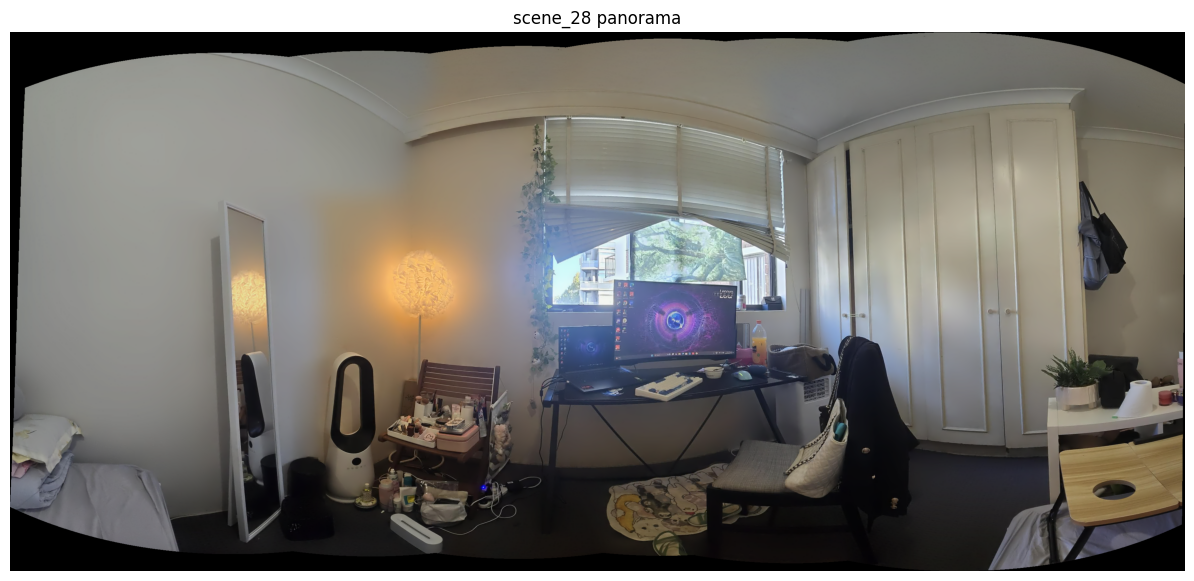

,scene_id,num_images,meta_capture_group,meta_category,meta_difficulty,meta_stitcher_status,meta_ok_rate,meta_stability_label,meta_output_consistent,status_name,panorama_shape,panorama_path,log_path
0,scene_28,6,core,pending_review,unknown,OK,1.0,stable_success,True,OK,"{'width': 3390, 'height': 1556}",F:\CV\School\Project\outputs\openCV\panoramas\...,F:\CV\School\Project\outputs\openCV\logs\scene...


**Scene notes:** none

**Metadata stability:** stable_success | ok_rate=1.0 | output_consistent=True

,pair_index,image_a,image_b,raw_matches,good_matches,inliers,inlier_ratio,homography_ok,median_reproj_error,pair_label
0,1,img_001.jpg,img_002.jpg,4000,328,260,0.793,True,1.460,strong
1,2,img_002.jpg,img_003.jpg,4000,629,573,0.911,True,1.336,strong
2,3,img_003.jpg,img_004.jpg,4000,582,431,0.741,True,1.390,strong
3,4,img_004.jpg,img_005.jpg,4000,1061,824,0.777,True,1.419,strong
4,5,img_005.jpg,img_006.jpg,4000,537,451,0.840,True,1.373,strong


In [37]:
single_result = run_scene(
    scene_id=SCENE_ID,
    max_input_width=MAX_INPUT_WIDTH,
    mode_name=STITCHER_MODE,
    save_outputs=SAVE_OUTPUTS,
)

display(pd.DataFrame([
    {
        "scene_id": single_result["scene_id"],
        "num_images": single_result["num_images"],
        "meta_capture_group": single_result["meta_capture_group"],
        "meta_category": single_result["meta_category"],
        "meta_difficulty": single_result["meta_difficulty"],
        "meta_stitcher_status": single_result["meta_stitcher_status"],
        "meta_ok_rate": single_result["meta_ok_rate"],
        "meta_stability_label": single_result["meta_stability_label"],
        "meta_output_consistent": single_result["meta_output_consistent"],
        "status_name": single_result["status_name"],
        "panorama_shape": single_result["panorama_shape"],
        "panorama_path": single_result["panorama_path"],
        "log_path": single_result["log_path"],
    }
]))

display(Markdown(f"**Scene notes:** {single_result['meta_notes']}" if single_result["meta_notes"] else "**Scene notes:** none"))
display(
    Markdown(
        f"**Metadata stability:** {single_result['meta_stability_label']} | "
        f"ok_rate={single_result['meta_ok_rate']} | "
        f"output_consistent={single_result['meta_output_consistent']}"
        if single_result["meta_stability_label"] is not None
        else "**Metadata stability:** none"
    )
)
display(pd.DataFrame(single_result["pair_diagnostics"]))


,scene_id,overlay_path,log_path,num_images,num_reference_images
0,scene_28,F:\CV\School\Project\outputs\openCV\overlays\s...,F:\CV\School\Project\outputs\openCV\logs\scene...,6,0


,file,method,good_matches,inliers,inlier_ratio,confidence,match_hull_area_ratio,projected_area_ratio
0,img_001.jpg,orb_clahe,241,113,0.469,high,0.0038,NaN
1,img_002.jpg,orb_clahe,863,535,0.620,high,0.0090,0.6530
2,img_003.jpg,orb_clahe,1147,467,0.407,high,0.0270,0.7457
3,img_004.jpg,orb_clahe,1412,654,0.463,high,0.0448,0.5975
4,img_005.jpg,orb_clahe,1085,480,0.442,high,0.0395,0.8708
5,img_006.jpg,orb_clahe,885,369,0.417,high,0.0088,NaN


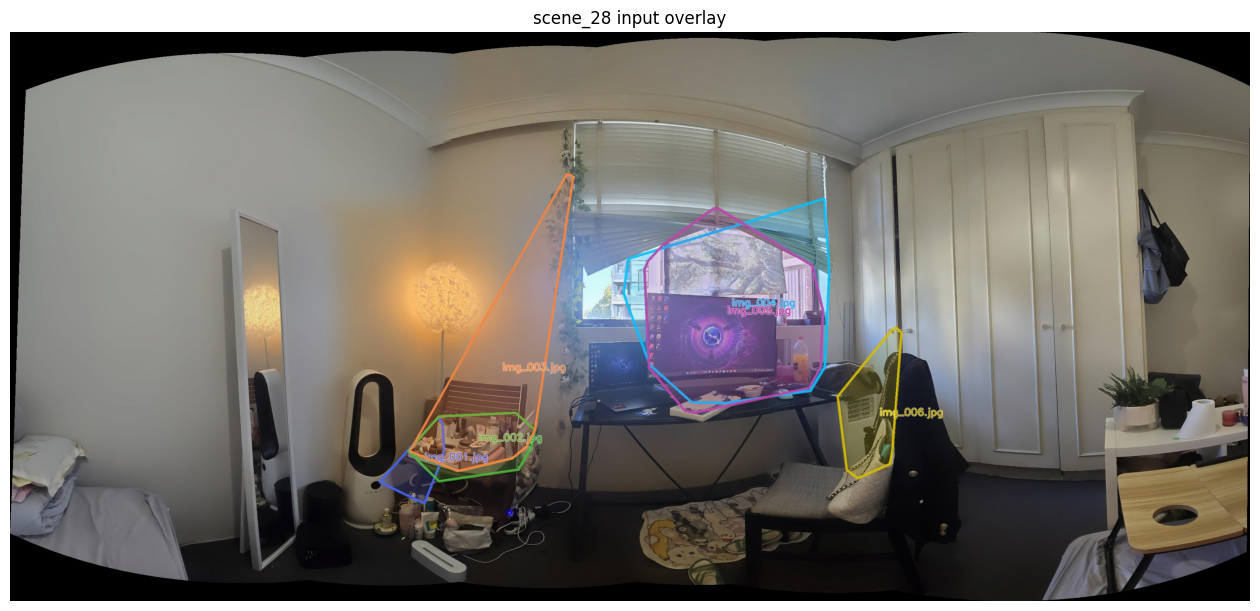

In [38]:
from scripts.generate_opencv_overlay import generate_overlay

overlay_result = generate_overlay(SCENE_ID)

display(pd.DataFrame([
    {
        "scene_id": overlay_result["scene_id"],
        "overlay_path": overlay_result["overlay_path"],
        "log_path": overlay_result["log_path"],
        "num_images": len(overlay_result["ordered_files"]),
        "num_reference_images": len(overlay_result["reference_files"]),
    }
]))

overlay_df = pd.DataFrame(overlay_result["per_image_overlay"])
if not overlay_df.empty:
    display(
        overlay_df[
            [
                "file",
                "method",
                "good_matches",
                "inliers",
                "inlier_ratio",
                "confidence",
                "match_hull_area_ratio",
                "projected_area_ratio",
            ]
        ]
    )

overlay_image = cv2.imread(overlay_result["overlay_path"])
if overlay_image is None:
    print("Could not read overlay image.")
else:
    plt.figure(figsize=(16, 8))
    plt.imshow(bgr_to_rgb(overlay_image))
    plt.title(f"{SCENE_ID} input overlay")
    plt.axis("off")
    plt.show()

## Run All Scenes

Cell này chỉ chạy khi `RUN_ALL_SCENES = True`.

Nó sẽ:
- stitch toàn bộ scene trong `data/raw`
- lưu từng summary JSON riêng lẻ
- tạo một file CSV tổng hợp trong `outputs/openCV/logs/`

In [39]:
if RUN_ALL_SCENES:
    batch_rows = []
    for scene_id in scene_table["scene_id"]:
        print(f"Running {scene_id} ...")
        result = run_scene(
            scene_id=scene_id,
            max_input_width=MAX_INPUT_WIDTH,
            mode_name=STITCHER_MODE,
            save_outputs=SAVE_OUTPUTS,
        )
        batch_rows.append(
            {
                "scene_id": result["scene_id"],
                "num_images": result["num_images"],
                "meta_capture_group": result["meta_capture_group"],
                "meta_category": result["meta_category"],
                "meta_difficulty": result["meta_difficulty"],
                "meta_stitcher_status": result["meta_stitcher_status"],
                "meta_ok_rate": result["meta_ok_rate"],
                "meta_stability_label": result["meta_stability_label"],
                "meta_output_consistent": result["meta_output_consistent"],
                "status_code": result["status_code"],
                "status_name": result["status_name"],
                "panorama_path": result["panorama_path"],
                "log_path": result["log_path"],
            }
        )

    batch_df = pd.DataFrame(batch_rows).sort_values(
        ["status_code", "meta_ok_rate", "scene_id"],
        ascending=[True, False, True],
    ).reset_index(drop=True)
    batch_csv_path = OUTPUT_LOG_DIR / f"batch_summary_{STITCHER_MODE.lower()}.csv"
    batch_df.to_csv(batch_csv_path, index=False)
    display(batch_df)
    print("Saved batch summary to:", batch_csv_path)
else:
    print("Set RUN_ALL_SCENES = True and rerun this cell to stitch every scene.")


Set RUN_ALL_SCENES = True and rerun this cell to stitch every scene.


## Quick Notes

- Nếu một scene báo `ERR_NEED_MORE_IMGS`, thường nghĩa là OpenCV không thấy đủ ảnh/cặp đủ tin cậy để dựng panorama.
- Nếu báo `ERR_HOMOGRAPHY_EST_FAIL`, thường là một hoặc nhiều cặp không ước lượng được homography ổn định.
- Nếu báo `ERR_CAMERA_PARAMS_ADJUST_FAIL`, thường là ghép cặp cục bộ còn được nhưng tối ưu toàn chuỗi bị vỡ.
- Bạn có thể đổi `STITCHER_MODE` sang `SCANS` để thử xem scene nào hợp với kiểu scan hơn panorama.
- Nếu muốn so sánh với pipeline tự cài đặt, hãy giữ output của notebook này trong `outputs/openCV/` và để pipeline manual ghi vào `outputs/manual/`.